# Markovianity Analysis of Decoding State Representations
All analyses condition on **state-action pairs** (S_t, A_t) -> S_{t+1}.
Per-action Markov State Models are fitted for each representation.
VAMP is trained with one-hot action concatenated to the continuous state features.

In [12]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import scipy.sparse as sp
from tqdm.notebook import tqdm
import time
import sys
import os

sys.path.append(os.path.abspath('ldpc/src_python'))

from RELDEC.algorithms.reldec_core import load_parity_check_from_sparse_csv
from RELDEC.algorithms.reldec_deep import build_cn_clusters, _cluster_mutual_information_vector
from ldpc.bp_decoder import BpDecoder

import deeptime.clustering as clst
import deeptime.markov as markov
from deeptime.decomposition import VAMP
import torch
import torch.nn as nn
from deeptime.markov.msm import MaximumLikelihoodMSM

# ---- Configuration (mutable) ----
MATRIX_CSV    = "RELDEC/matrices/H_Mackay_96_48.csv"
CLUSTER_SIZE  = 4
SNR_DB        = 2.0
NUM_EPISODES  = 1000
L_MAX         = 50
BINS          = 21
SEED          = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
print("Configuration Loaded.")


Configuration Loaded.


In [13]:
h_csr = load_parity_check_from_sparse_csv(MATRIX_CSV)
m, n = h_csr.shape
map_clusters = build_cn_clusters(h_csr, CLUSTER_SIZE)
num_actions = len(map_clusters.clusters)
print(f"Matrix shape: {h_csr.shape}, Num actions: {num_actions}")

decoder = BpDecoder(
    h_csr.tocsr().astype(np.uint8),
    max_iter=1,
    schedule="cluster",
    input_vector_type="received_vector",
)

def get_channel_llrs(snr_db, n_bits):
    snr_linear = 10 ** (snr_db / 10.0)
    sigma = np.sqrt(1.0 / (2.0 * snr_linear))
    received = 1.0 + np.random.randn(n_bits) * sigma
    return 2.0 * received / (sigma ** 2)


Matrix shape: (48, 96), Num actions: 12


In [14]:
episodes_data = []
start_time = time.time()
rng = np.random.default_rng(SEED)

for ep in tqdm(range(NUM_EPISODES), desc="MC Sampling"):
    llr_channel = get_channel_llrs(SNR_DB, n)
    decoder.reset()
    decoder.initialise_log_domain_bp(np.asarray(llr_channel, dtype=np.float64))
    trajectory = []
    for step in range(L_MAX):
        llr_post = np.asarray(decoder.log_prob_ratios, dtype=np.float64)
        action = rng.integers(0, num_actions)
        decoder.decode_cluster(map_clusters.clusters[action])
        next_llr_post = np.asarray(decoder.log_prob_ratios, dtype=np.float64)
        trajectory.append((llr_post.copy(), int(action), next_llr_post.copy()))
        hard_decision = (next_llr_post < 0).astype(np.uint8)
        if not (h_csr @ hard_decision % 2).any():
            break
    episodes_data.append(trajectory)

print(f"Collected {len(episodes_data)} episodes in {time.time() - start_time:.2f}s")


MC Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Collected 1000 episodes in 1.69s


In [15]:
# All representations store (s_t, a_t, s_t1) for SA-pair conditioning
rep_keys = ["full_llr", "full_tanh_llr", "avg_llr_cluster", "mi_cluster", "full_llr_mi"]
transitions = {k: {"s_t": [], "s_t1": [], "a_t": []} for k in rep_keys}

print("Processing state representations...")
start_time = time.time()

for trajectory in tqdm(episodes_data, desc="Processing episodes"):
    for llr_t, action, llr_t1 in trajectory:
        s_full     = llr_t
        s1_full    = llr_t1
        s_tanh     = np.tanh(llr_t / 2.0)
        s1_tanh    = np.tanh(llr_t1 / 2.0)
        s_avg      = np.array([np.mean(np.abs(llr_t[nb])) if nb.size > 0 else 0.0
                               for nb in map_clusters.cluster_neighbors])
        s1_avg     = np.array([np.mean(np.abs(llr_t1[nb])) if nb.size > 0 else 0.0
                               for nb in map_clusters.cluster_neighbors])
        s_mi       = _cluster_mutual_information_vector(llr_t,  map_clusters.cluster_neighbors)
        s1_mi      = _cluster_mutual_information_vector(llr_t1, map_clusters.cluster_neighbors)
        s_full_mi  = np.concatenate([s_full, s_mi])
        s1_full_mi = np.concatenate([s1_full, s1_mi])

        for key, s_t, s_t1 in [
            ("full_llr",       s_full,    s1_full),
            ("full_tanh_llr",  s_tanh,    s1_tanh),
            ("avg_llr_cluster",s_avg,     s1_avg),
            ("mi_cluster",     s_mi,      s1_mi),
            ("full_llr_mi",    s_full_mi, s1_full_mi),
        ]:
            transitions[key]["s_t"].append(s_t)
            transitions[key]["s_t1"].append(s_t1)
            transitions[key]["a_t"].append(action)

for k in transitions:
    transitions[k]["s_t"]  = np.array(transitions[k]["s_t"],  dtype=np.float32)
    transitions[k]["s_t1"] = np.array(transitions[k]["s_t1"], dtype=np.float32)
    transitions[k]["a_t"]  = np.array(transitions[k]["a_t"],  dtype=np.int32)

N = len(transitions["full_llr"]["a_t"])
onehot_actions = np.zeros((N, num_actions), dtype=np.float32)
onehot_actions[np.arange(N), transitions["full_llr"]["a_t"]] = 1.0

print(f"Done in {time.time()-start_time:.2f}s. Transitions: {N}, ~{N//num_actions} per action.")


Processing state representations...


Processing episodes:   0%|          | 0/1000 [00:00<?, ?it/s]

Done in 9.73s. Transitions: 11689, ~974 per action.


Fitting per-action MSMs:   0%|          | 0/4 [00:00<?, ?it/s]

Per-action MSMs fitted.


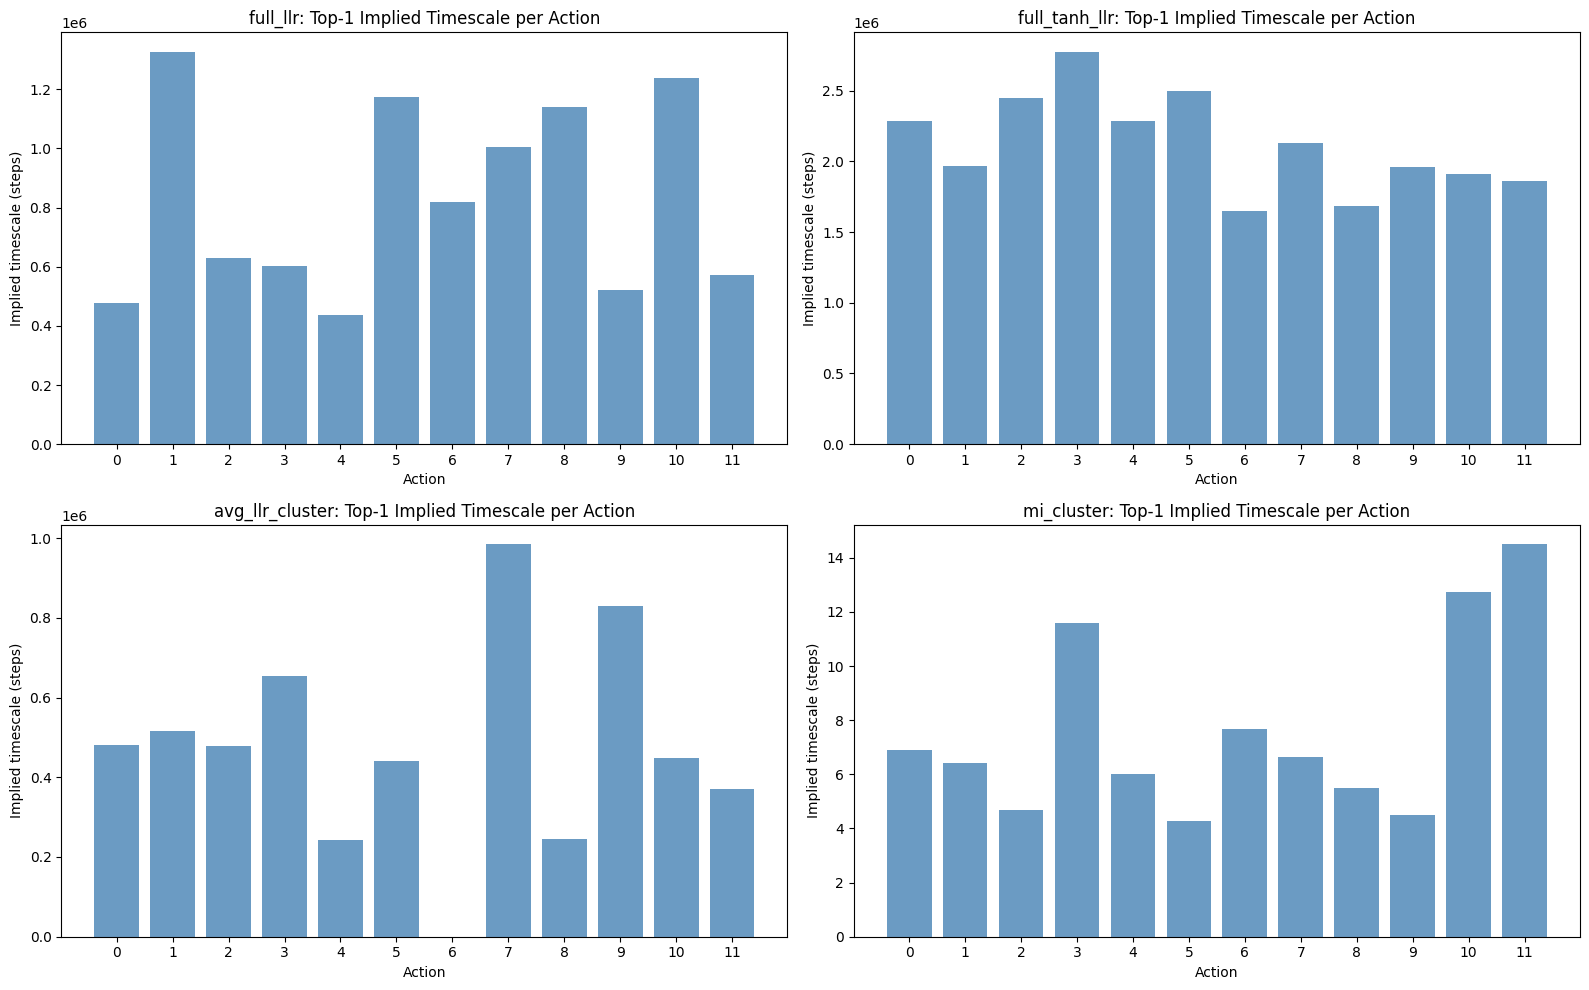

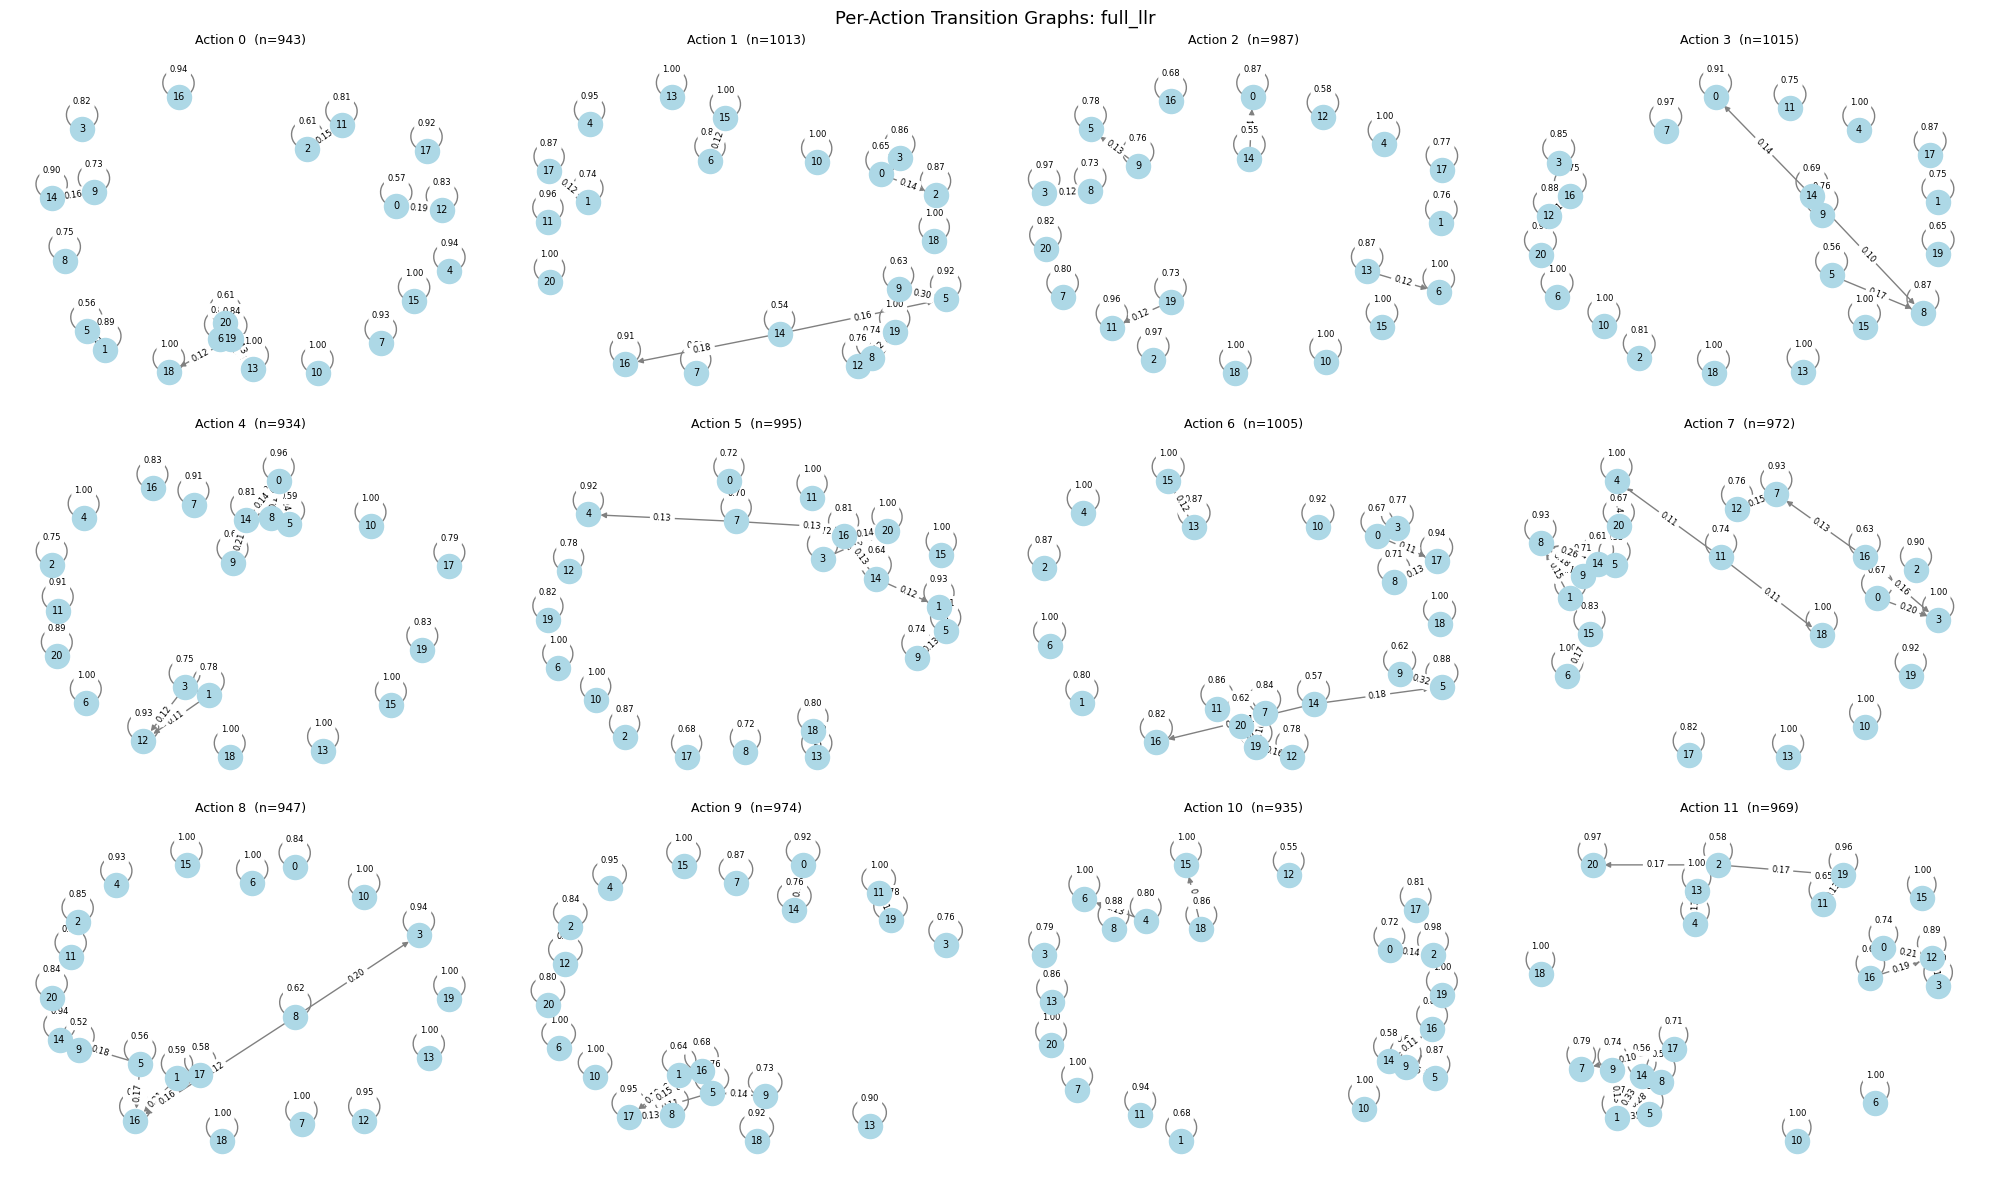


--- Mean Top-3 Implied Timescales (averaged over actions) ---
            full_llr: [827964.41 592787.3  399253.59]
       full_tanh_llr: [2120422.57 1733744.87 1534150.41]
     avg_llr_cluster: [474504.2   50469.08  23818.99]
          mi_cluster: [7.62 4.99 3.95]


In [16]:
# Discretize each representation with k-means (consistent across all actions),
# then build per-action transition matrices P(S'|S, A=a).

heuristic_reps = ["full_llr", "full_tanh_llr", "avg_llr_cluster", "mi_cluster"]

# msm_models[rep][a] = BINS x BINS transition matrix
msm_models    = {rep: {} for rep in heuristic_reps}
cluster_models = {}   # saves (cluster_obj, dtrajs_t, dtrajs_t1) per rep

def get_implied_timescales(P, lag=1):
    evals = np.sort(np.abs(np.linalg.eigvals(P)))[::-1][1:]  # drop stationary
    ts = np.zeros_like(evals, dtype=float)
    valid = evals > 1e-10
    ts[valid] = -lag / np.log(evals[valid])
    return ts

for rep_name in tqdm(heuristic_reps, desc="Fitting per-action MSMs"):
    data_t  = transitions[rep_name]["s_t"]
    data_t1 = transitions[rep_name]["s_t1"]
    a_t     = transitions[rep_name]["a_t"]

    # Cluster ALL data together (state IDs consistent across actions)
    clust = clst.KMeans(n_clusters=BINS, max_iter=50)
    dt  = clust.fit_transform(data_t)
    dt1 = clust.transform(data_t1)
    cluster_models[rep_name] = (clust, dt, dt1)

    for a in range(num_actions):
        mask = a_t == a
        if mask.sum() < 2:
            continue
        C = np.zeros((BINS, BINS))
        for i in np.where(mask)[0]:
            C[dt[i], dt1[i]] += 1
        C += 1e-6
        msm_models[rep_name][a] = C / C.sum(axis=1, keepdims=True)

print("Per-action MSMs fitted.")

# --- Bar chart: top-1 implied timescale per action per rep ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for idx, rep_name in enumerate(heuristic_reps):
    ax = axes[idx]
    ts_top1 = [get_implied_timescales(msm_models[rep_name][a])[0]
               if a in msm_models[rep_name] else 0 for a in range(num_actions)]
    ax.bar(range(num_actions), ts_top1, color="steelblue", alpha=0.8)
    ax.set_title(f"{rep_name}: Top-1 Implied Timescale per Action")
    ax.set_xlabel("Action")
    ax.set_ylabel("Implied timescale (steps)")
    ax.set_xticks(range(num_actions))
plt.tight_layout()
plt.show()

# --- Per-action transition graphs for full_llr ---
_, dt_full, dt1_full = cluster_models["full_llr"]
a_t_full = transitions["full_llr"]["a_t"]
ncols = 4
nrows = (num_actions + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for a in range(num_actions):
    ax = axes[a]
    P = msm_models["full_llr"].get(a)
    if P is None:
        ax.axis("off"); continue
    G = nx.DiGraph()
    for u in range(BINS):
        for v in range(BINS):
            if P[u, v] > 0.10:
                G.add_edge(u, v, weight=P[u, v])
    pos = nx.spring_layout(G, seed=SEED)
    nx.draw(G, pos, ax=ax, with_labels=True, node_color="lightblue",
            node_size=300, font_size=7, edge_color="gray", arrows=True, arrowsize=8)
    nx.draw_networkx_edge_labels(G, pos,
        edge_labels={(u,v): f"{d['weight']:.2f}" for u,v,d in G.edges(data=True)},
        ax=ax, font_size=6)
    ax.set_title(f"Action {a}  (n={(a_t_full==a).sum()})", fontsize=9)
for a in range(num_actions, len(axes)):
    axes[a].axis("off")
plt.suptitle("Per-Action Transition Graphs: full_llr", fontsize=13)
plt.tight_layout()
plt.show()

# --- Summary table ---
print("\n--- Mean Top-3 Implied Timescales (averaged over actions) ---")
for rep_name in heuristic_reps:
    all_ts = [get_implied_timescales(msm_models[rep_name][a])[:3]
              for a in range(num_actions) if a in msm_models[rep_name]]
    print(f"{rep_name:>20}: {np.round(np.mean(all_ts, axis=0), 2)}")



--- Action-Conditioned VAMP (Full LLR + MI + One-Hot Action) ---
VAMP projection completed in 2.25s
VAMP-2 Score (action-conditioned, Full LLR+MI+Action): 100.4776


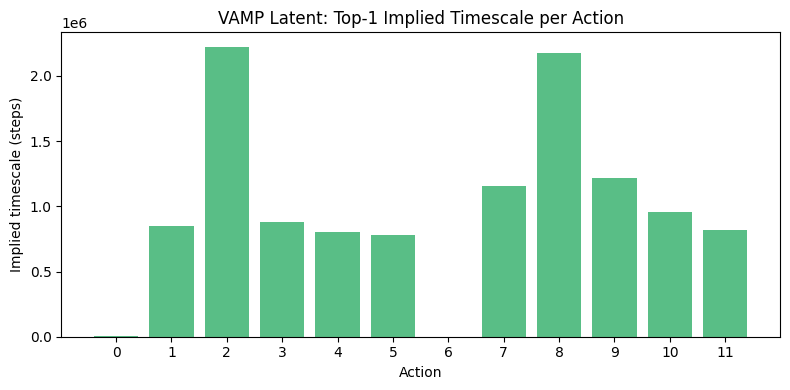

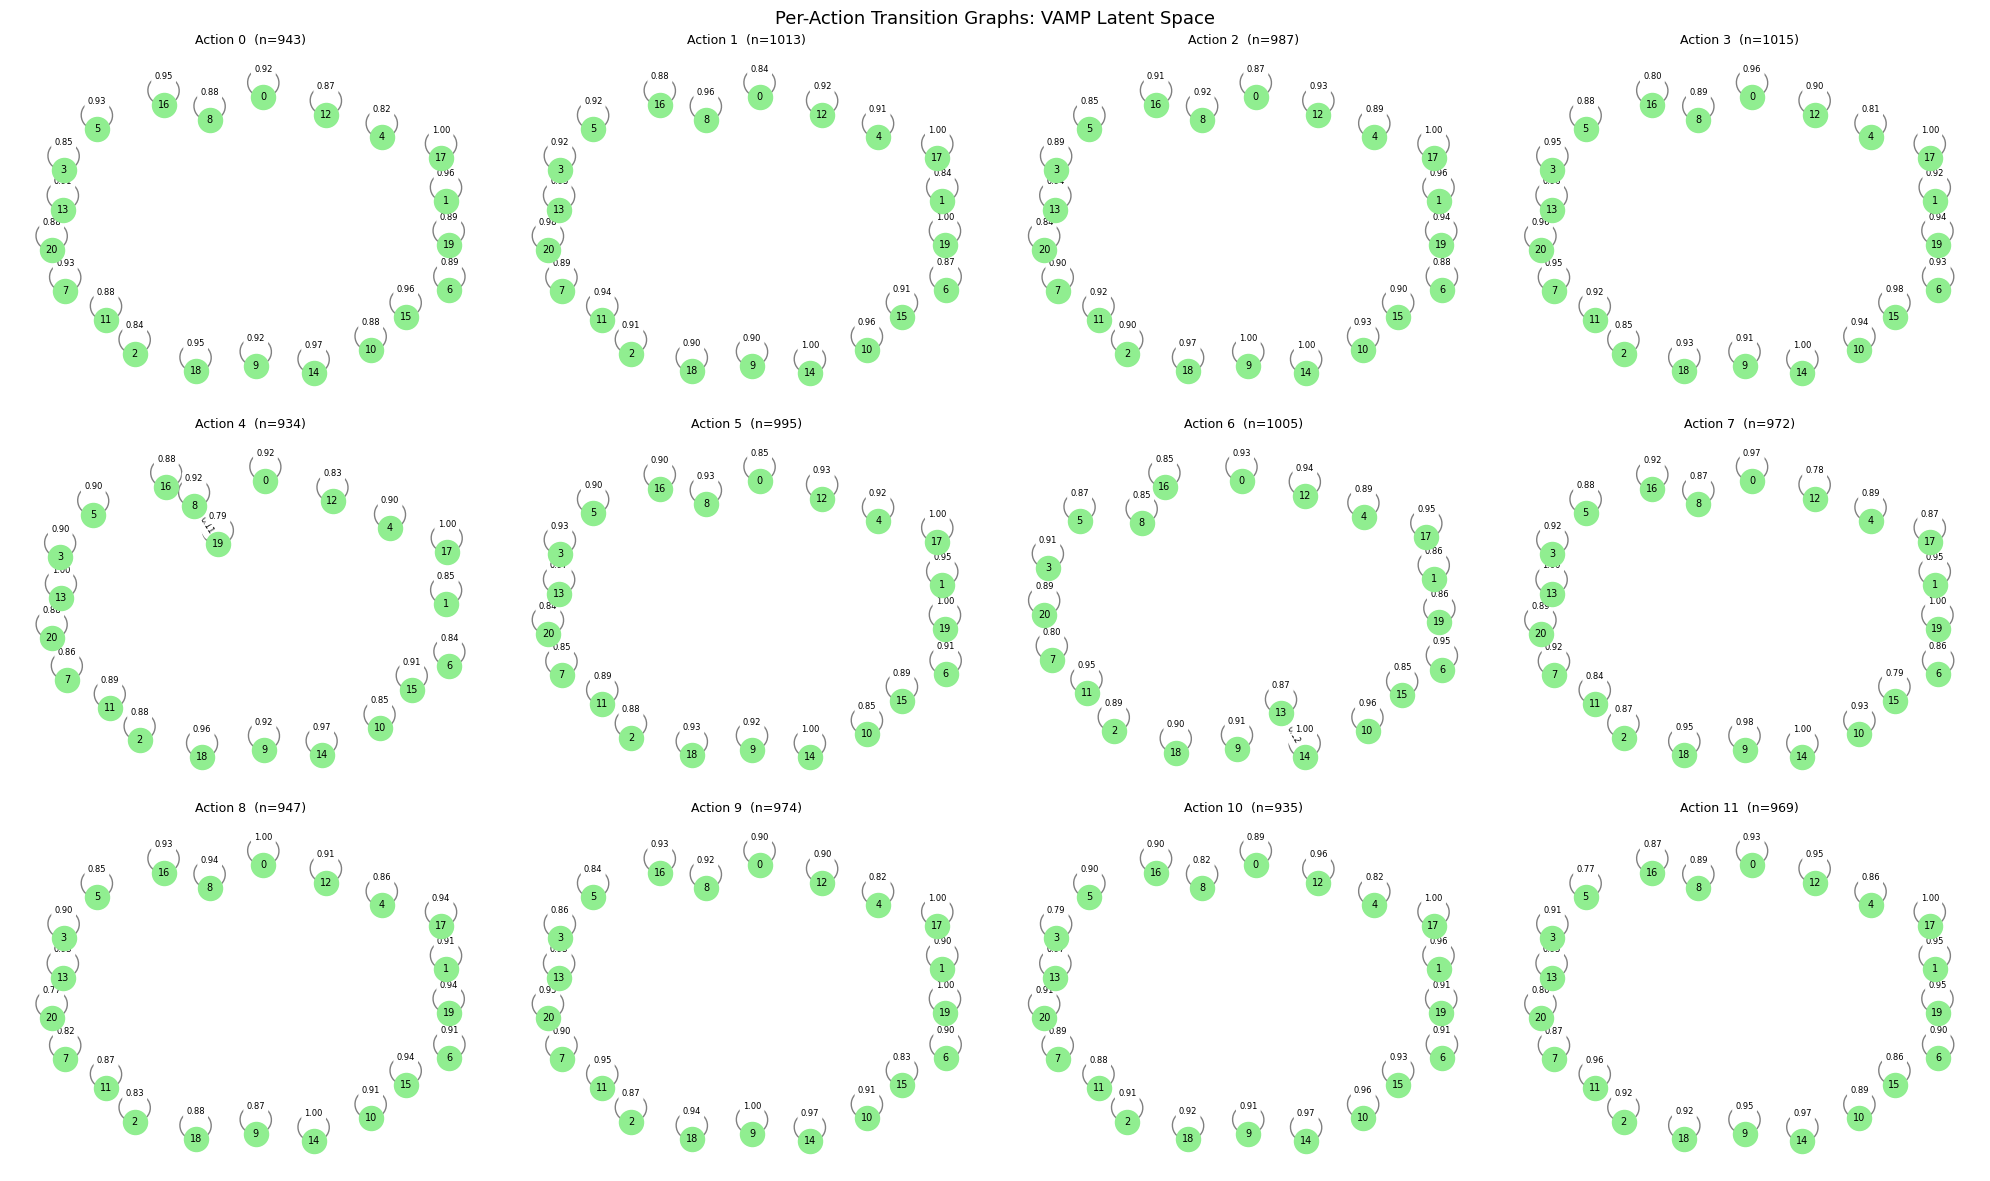


VAMP_latent mean top-3 timescales: [9.8935356e+05 2.5524089e+05 2.9899000e+02]


In [17]:
# Action-conditioned VAMP: concatenate one-hot(A_t) to S_t features.
# x_t  = [S_t,  onehot(A_t)]   (what we know at decision time)
# x_t1 = [S_t1, zeros]         (future state; action unknown)
print("\n--- Action-Conditioned VAMP (Full LLR + MI + One-Hot Action) ---")
st = time.time()

data_s_t  = transitions["full_llr_mi"]["s_t"]
data_s_t1 = transitions["full_llr_mi"]["s_t1"]

vamp_in_t  = np.concatenate([data_s_t,  onehot_actions], axis=1).astype(np.float32)
vamp_in_t1 = np.concatenate([data_s_t1, np.zeros_like(onehot_actions)], axis=1).astype(np.float32)

vamp = VAMP(dim=10, lagtime=1)
vamp.fit((vamp_in_t, vamp_in_t1))

latent_t  = vamp.transform(vamp_in_t)
latent_t1 = vamp.transform(vamp_in_t1)

vscore = np.sum(vamp.fetch_model().singular_values ** 2)
print(f"VAMP projection completed in {time.time()-st:.2f}s")
print(f"VAMP-2 Score (action-conditioned, Full LLR+MI+Action): {vscore:.4f}")

# Discretize VAMP latent space
clust_vamp = clst.KMeans(n_clusters=BINS, max_iter=50)
dtrajs_vamp_t  = clust_vamp.fit_transform(latent_t)
dtrajs_vamp_t1 = clust_vamp.transform(latent_t1)

# Build per-action transition matrices in VAMP latent space
a_t_all = transitions["full_llr"]["a_t"]
msm_models["VAMP_latent"] = {}
for a in range(num_actions):
    mask = a_t_all == a
    if mask.sum() < 2:
        continue
    C = np.zeros((BINS, BINS))
    for i in np.where(mask)[0]:
        C[dtrajs_vamp_t[i], dtrajs_vamp_t1[i]] += 1
    C += 1e-6
    msm_models["VAMP_latent"][a] = C / C.sum(axis=1, keepdims=True)

# Timescale bar chart for VAMP latent
ts_top1_vamp = [get_implied_timescales(msm_models["VAMP_latent"][a])[0]
                if a in msm_models["VAMP_latent"] else 0 for a in range(num_actions)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(num_actions), ts_top1_vamp, color="mediumseagreen", alpha=0.85)
ax.set_title("VAMP Latent: Top-1 Implied Timescale per Action")
ax.set_xlabel("Action"); ax.set_ylabel("Implied timescale (steps)")
ax.set_xticks(range(num_actions))
plt.tight_layout(); plt.show()

# Per-action transition graphs for VAMP latent
ncols = 4; nrows = (num_actions + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
for a in range(num_actions):
    ax = axes[a]
    P = msm_models["VAMP_latent"].get(a)
    if P is None:
        ax.axis("off"); continue
    G = nx.DiGraph()
    for u in range(BINS):
        for v in range(BINS):
            if P[u, v] > 0.10:
                G.add_edge(u, v, weight=P[u, v])
    pos = nx.spring_layout(G, seed=SEED)
    nx.draw(G, pos, ax=ax, with_labels=True, node_color="lightgreen",
            node_size=300, font_size=7, edge_color="gray", arrows=True, arrowsize=8)
    nx.draw_networkx_edge_labels(G, pos,
        edge_labels={(u,v): f"{d['weight']:.2f}" for u,v,d in G.edges(data=True)},
        ax=ax, font_size=6)
    ax.set_title(f"Action {a}  (n={(a_t_all==a).sum()})", fontsize=9)
for a in range(num_actions, len(axes)):
    axes[a].axis("off")
plt.suptitle("Per-Action Transition Graphs: VAMP Latent Space", fontsize=13)
plt.tight_layout(); plt.show()

all_ts_vamp = [get_implied_timescales(msm_models["VAMP_latent"][a])[:3]
               for a in range(num_actions) if a in msm_models["VAMP_latent"]]
print(f"\nVAMP_latent mean top-3 timescales: {np.round(np.mean(all_ts_vamp, axis=0), 2)}")


In [18]:
all_reps = heuristic_reps + ["VAMP_latent"]

# 1. Next-State Predictability — (S_t, A_t) -> S_{t+1}
print("\n--- Next-State Predictability Accuracy (S_t, A_t) -> S_{t+1} ---")
print("Mode prediction accuracy: how often the most frequent next state actually occurs.")

for rep_name in all_reps:
    if rep_name == "VAMP_latent":
        dt_rep, dt1_rep = dtrajs_vamp_t, dtrajs_vamp_t1
    else:
        _, dt_rep, dt1_rep = cluster_models[rep_name]

    a_t = transitions["full_llr"]["a_t"]
    cnt = {}
    for i in range(len(dt_rep)):
        key = (int(dt_rep[i]), int(a_t[i]))
        s1  = int(dt1_rep[i])
        cnt.setdefault(key, {})
        cnt[key][s1] = cnt[key].get(s1, 0) + 1

    correct = sum(max(v.values()) for v in cnt.values())
    total   = sum(sum(v.values()) for v in cnt.values())
    print(f"{rep_name:>20}: {correct/total*100:.2f}% deterministic predictability")

# 2. Per-Action Chapman-Kolmogorov Test
print("\n--- Per-Action Chapman-Kolmogorov Test ---")
print("P^n_a (predicted) vs P_a(n) (empirical). Mean |diff| over actions and lags.")

for rep_name in all_reps:
    if rep_name == "VAMP_latent":
        dtrajs_all = dtrajs_vamp_t
    else:
        _, dtrajs_all, _ = cluster_models[rep_name]

    a_t = transitions["full_llr"]["a_t"]
    per_action_diffs = []

    for a in range(num_actions):
        dtrajs_a = dtrajs_all[a_t == a]
        if len(dtrajs_a) < 20:
            continue
        try:
            n_meta = min(5, BINS)
            models_list = [MaximumLikelihoodMSM(lagtime=l).fit([dtrajs_a]).fetch_model()
                           for l in range(1, 6)]
            ck    = models_list[0].ck_test(models=models_list, n_metastable_sets=n_meta)
            preds = np.real(ck.predictions)
            ests  = np.real(ck.estimates)
            diffs = [abs(np.diag(preds[l]).mean() - np.diag(ests[l]).mean())
                     for l in range(1, len(preds))]
            per_action_diffs.append(np.mean(diffs))
        except Exception:
            pass

    if per_action_diffs:
        print(f"{rep_name:>20}: mean |CK diff| = {np.mean(per_action_diffs):.4f}  "
              f"(max = {np.max(per_action_diffs):.4f})")
    else:
        print(f"{rep_name:>20}: CK test insufficient data per action")



--- Next-State Predictability Accuracy (S_t, A_t) -> S_{t+1} ---
Mode prediction accuracy: how often the most frequent next state actually occurs.
            full_llr: 76.35% deterministic predictability
       full_tanh_llr: 91.22% deterministic predictability
     avg_llr_cluster: 64.45% deterministic predictability
          mi_cluster: 62.88% deterministic predictability
         VAMP_latent: 90.70% deterministic predictability

--- Per-Action Chapman-Kolmogorov Test ---
P^n_a (predicted) vs P_a(n) (empirical). Mean |diff| over actions and lags.
            full_llr: mean |CK diff| = 0.0038  (max = 0.0120)
       full_tanh_llr: mean |CK diff| = 0.0086  (max = 0.0178)
     avg_llr_cluster: mean |CK diff| = 0.0022  (max = 0.0044)
          mi_cluster: mean |CK diff| = 0.0021  (max = 0.0038)
         VAMP_latent: mean |CK diff| = 0.0041  (max = 0.0126)
